In [1]:
# =============================================================
# NB04 — MODÈLES BASELINE
# =============================================================
# SECTION 0 — IMPORTS ET CONFIGURATION
# =============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import time
from pathlib import Path

# Modèles
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

# Métriques
from sklearn.metrics import (
    roc_auc_score, average_precision_score, recall_score,
    precision_score, fbeta_score, brier_score_loss, accuracy_score,
    confusion_matrix, roc_curve, precision_recall_curve,
)

# Seed
SEED = 42
np.random.seed(SEED)

# Style
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 12
pd.set_option("display.max_columns", None)
pd.set_option("display.precision", 4)

# Dossiers de sortie
DATA_PROC = Path("../data/processed")
MODELS    = Path("../models")
REPORTS   = Path("../reports")
FIGURES   = Path("../figures")
for d in [MODELS, REPORTS, FIGURES]:
    d.mkdir(parents=True, exist_ok=True)

print("✓ Environnement configuré.")
print(f"  Dossiers créés : models/, reports/, figures/")

✓ Environnement configuré.
  Dossiers créés : models/, reports/, figures/


In [2]:
# =============================================================
# SECTION 1 — CHARGEMENT DES DONNÉES PREPROCESSÉES
# =============================================================

# Les données viennent du NB03 : déjà imputées, scalées, one-hot.
# On entraîne DIRECTEMENT dessus (pas de re-preprocessing ici).
X_train = pd.read_pickle(DATA_PROC / "X_train.pkl")
X_val   = pd.read_pickle(DATA_PROC / "X_val.pkl")
X_test  = pd.read_pickle(DATA_PROC / "X_test.pkl")   # chargé mais NON utilisé ici
y_train = pd.read_pickle(DATA_PROC / "y_train.pkl")
y_val   = pd.read_pickle(DATA_PROC / "y_val.pkl")
y_test  = pd.read_pickle(DATA_PROC / "y_test.pkl")   # chargé mais NON utilisé ici

print("=" * 55)
print("DONNÉES CHARGÉES")
print("=" * 55)
print(f"  X_train : {X_train.shape}")
print(f"  X_val   : {X_val.shape}")
print(f"  Features: {X_train.shape[1]}")
print("\n  ⚠️  X_test / y_test chargés mais NON utilisés (réservés au NB07).")

DONNÉES CHARGÉES
  X_train : (48990, 186)
  X_val   : (10498, 186)
  Features: 186

  ⚠️  X_test / y_test chargés mais NON utilisés (réservés au NB07).


In [3]:
# =============================================================
# SECTION 2 — VÉRIFICATIONS PRÉLIMINAIRES
# =============================================================

print("=" * 55)
print("DISTRIBUTION DE LA CIBLE")
print("=" * 55)
for nom, yy in [("Train", y_train), ("Val", y_val)]:
    n_pos = int(yy.sum())
    n_neg = int((yy == 0).sum())
    print(f"  {nom:<6} : {len(yy):>6,} | positifs {n_pos:>5,} "
          f"({yy.mean()*100:.2f}%) | négatifs {n_neg:>6,}")

# Ratio de déséquilibre — calculé sur y_train UNIQUEMENT (anti-leakage)
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

print("\n" + "=" * 55)
print("RATIO DE DÉSÉQUILIBRE")
print("=" * 55)
print(f"  scale_pos_weight = {scale_pos_weight:.2f}  (négatifs / positifs, train)")
print(f"  → sera utilisé pour XGBoost")

# Colonnes alignées entre train et val ?
assert list(X_train.columns) == list(X_val.columns), "❌ Colonnes désalignées !"
print("\n✓ Colonnes train/val alignées.")

DISTRIBUTION DE LA CIBLE
  Train  : 48,990 | positifs 4,399 (8.98%) | négatifs 44,591
  Val    : 10,498 | positifs   943 (8.98%) | négatifs  9,555

RATIO DE DÉSÉQUILIBRE
  scale_pos_weight = 10.14  (négatifs / positifs, train)
  → sera utilisé pour XGBoost

✓ Colonnes train/val alignées.


In [4]:
# =============================================================
# SECTION 3 — FONCTION D'ÉVALUATION
# =============================================================

def evaluate_model(model, X_val, y_val, model_name):
    """
    Évalue un modèle entraîné sur le VALIDATION set.
    Retourne un dictionnaire de toutes les métriques.
    Seuil de décision fixé à 0.5.
    """
    y_pred  = model.predict(X_val)
    y_proba = model.predict_proba(X_val)[:, 1]

    metrics = {
        "Modèle":      model_name,
        "ROC-AUC":     roc_auc_score(y_val, y_proba),
        "PR-AUC":      average_precision_score(y_val, y_proba),
        "Recall":      recall_score(y_val, y_pred),
        "Precision":   precision_score(y_val, y_pred),
        "F2-Score":    fbeta_score(y_val, y_pred, beta=2),
        "Brier Score": brier_score_loss(y_val, y_proba),
        "Accuracy":    accuracy_score(y_val, y_pred),  # affichée, hors décision
    }
    return metrics

# Conteneurs pour la suite
resultats = []          # liste de dicts de métriques
modeles_entraines = {}  # nom → modèle (pour visualisations et sauvegarde)
temps_entrainement = {} # nom → durée (s)

print("✓ Fonction d'évaluation prête.")

✓ Fonction d'évaluation prête.


In [5]:
# =============================================================
# SECTION 4 — LOGISTIC REGRESSION (baseline interprétable)
# =============================================================

print("Entraînement Logistic Regression...")
start = time.time()

lr = LogisticRegression(
    class_weight="balanced",   # gestion du déséquilibre
    max_iter=1000,
    random_state=SEED,
)
lr.fit(X_train, y_train)

duree = time.time() - start
temps_entrainement["Logistic Regression"] = duree
modeles_entraines["Logistic Regression"] = lr

# Évaluation sur val
m = evaluate_model(lr, X_val, y_val, "Logistic Regression")
resultats.append(m)

# Sauvegarde
joblib.dump(lr, MODELS / "lr_baseline.pkl")

print(f"✓ Terminé en {duree:.2f}s")
for k, v in m.items():
    if k != "Modèle":
        print(f"  {k:<12} : {v:.4f}")

Entraînement Logistic Regression...
✓ Terminé en 1.68s
  ROC-AUC      : 0.6668
  PR-AUC       : 0.1784
  Recall       : 0.5695
  Precision    : 0.1468
  F2-Score     : 0.3614
  Brier Score  : 0.2277
  Accuracy     : 0.6641


In [6]:
# =============================================================
# SECTION 5 — RANDOM FOREST (référence ensembliste)
# =============================================================

print("Entraînement Random Forest...")
start = time.time()

rf = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=SEED,
    n_jobs=-1,
)
rf.fit(X_train, y_train)

duree = time.time() - start
temps_entrainement["Random Forest"] = duree
modeles_entraines["Random Forest"] = rf

m = evaluate_model(rf, X_val, y_val, "Random Forest")
resultats.append(m)

joblib.dump(rf, MODELS / "rf_baseline.pkl")

print(f"✓ Terminé en {duree:.2f}s")
for k, v in m.items():
    if k != "Modèle":
        print(f"  {k:<12} : {v:.4f}")

Entraînement Random Forest...
✓ Terminé en 2.72s
  ROC-AUC      : 0.6530
  PR-AUC       : 0.1704
  Recall       : 0.0191
  Precision    : 0.3396
  F2-Score     : 0.0235
  Brier Score  : 0.0897
  Accuracy     : 0.9086


In [7]:
# =============================================================
# SECTION 6 — LIGHTGBM (candidat principal)
# =============================================================

print("Entraînement LightGBM...")
start = time.time()

lgbm = LGBMClassifier(
    is_unbalance=True,         # gestion du déséquilibre
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    random_state=SEED,
    n_jobs=-1,
    verbose=-1,
)
lgbm.fit(X_train, y_train)

duree = time.time() - start
temps_entrainement["LightGBM"] = duree
modeles_entraines["LightGBM"] = lgbm

m = evaluate_model(lgbm, X_val, y_val, "LightGBM")
resultats.append(m)

joblib.dump(lgbm, MODELS / "lgbm_baseline.pkl")

print(f"✓ Terminé en {duree:.2f}s")
for k, v in m.items():
    if k != "Modèle":
        print(f"  {k:<12} : {v:.4f}")

Entraînement LightGBM...
✓ Terminé en 1.56s
  ROC-AUC      : 0.6449
  PR-AUC       : 0.1766
  Recall       : 0.4390
  Precision    : 0.1590
  F2-Score     : 0.3247
  Brier Score  : 0.1825
  Accuracy     : 0.7410


In [8]:
# =============================================================
# SECTION 7 — XGBOOST (candidat secondaire)
# =============================================================

print("Entraînement XGBoost...")
start = time.time()

xgb = XGBClassifier(
    scale_pos_weight=scale_pos_weight,  # gestion du déséquilibre (ratio du train)
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    random_state=SEED,
    n_jobs=-1,
    eval_metric="aucpr",
)
xgb.fit(X_train, y_train)

duree = time.time() - start
temps_entrainement["XGBoost"] = duree
modeles_entraines["XGBoost"] = xgb

m = evaluate_model(xgb, X_val, y_val, "XGBoost")
resultats.append(m)

joblib.dump(xgb, MODELS / "xgb_baseline.pkl")

print(f"✓ Terminé en {duree:.2f}s")
for k, v in m.items():
    if k != "Modèle":
        print(f"  {k:<12} : {v:.4f}")

Entraînement XGBoost...
✓ Terminé en 3.78s
  ROC-AUC      : 0.6450
  PR-AUC       : 0.1737
  Recall       : 0.4655
  Precision    : 0.1457
  F2-Score     : 0.3235
  Brier Score  : 0.1963
  Accuracy     : 0.7068


In [9]:
# =============================================================
# SECTION 8 — TABLEAU COMPARATIF GLOBAL
# =============================================================

df_results = pd.DataFrame(resultats).set_index("Modèle")

# Ajout du temps d'entraînement
df_results["Temps (s)"] = pd.Series(temps_entrainement)

# Tri par PR-AUC (métrique prioritaire vu le déséquilibre)
df_results = df_results.sort_values("PR-AUC", ascending=False)

print("=" * 70)
print("TABLEAU COMPARATIF (évaluation sur VALIDATION set)")
print("=" * 70)
display(df_results.round(4))

# Meilleur score par métrique (les métriques où "plus haut = mieux")
print("\nMeilleur modèle par métrique :")
for col in ["ROC-AUC", "PR-AUC", "Recall", "Precision", "F2-Score"]:
    best = df_results[col].idxmax()
    print(f"  {col:<12} : {best} ({df_results.loc[best, col]:.4f})")
# Brier : plus BAS = mieux
best_brier = df_results["Brier Score"].idxmin()
print(f"  {'Brier Score':<12} : {best_brier} ({df_results.loc[best_brier, 'Brier Score']:.4f}) [plus bas = mieux]")

# Sauvegarde CSV
df_results.to_csv(REPORTS / "baseline_comparison.csv")
print(f"\n✓ Tableau sauvegardé : reports/baseline_comparison.csv")

TABLEAU COMPARATIF (évaluation sur VALIDATION set)


,ROC-AUC,PR-AUC,Recall,Precision,F2-Score,Brier Score,Accuracy,Temps (s)
Modèle,,,,,,,,
Logistic Regression,0.6668,0.1784,0.5695,0.1468,0.3614,0.2277,0.6641,1.6775
LightGBM,0.6449,0.1766,0.4390,0.1590,0.3247,0.1825,0.7410,1.5572
XGBoost,0.6450,0.1737,0.4655,0.1457,0.3235,0.1963,0.7068,3.7766
Random Forest,0.6530,0.1704,0.0191,0.3396,0.0235,0.0897,0.9086,2.7207



Meilleur modèle par métrique :
  ROC-AUC      : Logistic Regression (0.6668)
  PR-AUC       : Logistic Regression (0.1784)
  Recall       : Logistic Regression (0.5695)
  Precision    : Random Forest (0.3396)
  F2-Score     : Logistic Regression (0.3614)
  Brier Score  : Random Forest (0.0897) [plus bas = mieux]

✓ Tableau sauvegardé : reports/baseline_comparison.csv


### 📊 Lecture du tableau comparatif

Après correction de l'encodage des identifiants, **tous les modèles s'améliorent**
et se regroupent (PR-AUC entre 0,170 et 0,178). Aucun ne domine nettement — la
limite vient des **données** (signal faible), pas du modèle. Scores cohérents avec
Strack et al. 2014.

**Classement PR-AUC :** Logistic Regression (0,1784) ≈ LightGBM (0,1766) ≈
XGBoost (0,1737) > Random Forest (0,1704). Les écarts (< 0,005) sont **négligeables**.

**Le Random Forest illustre le piège de l'accuracy** : meilleure accuracy (0,91)
mais recall de 0,019 — il prédit quasi uniquement la classe majoritaire. D'où
l'exclusion de l'accuracy du critère de décision.

**La Logistic Regression profite le plus de la correction d'encodage** : modèle
linéaire, elle était la plus pénalisée par les identifiants traités comme numériques
(faux ordre). Une fois one-hot encodés, elle passe de PR-AUC 0,151 à 0,178.

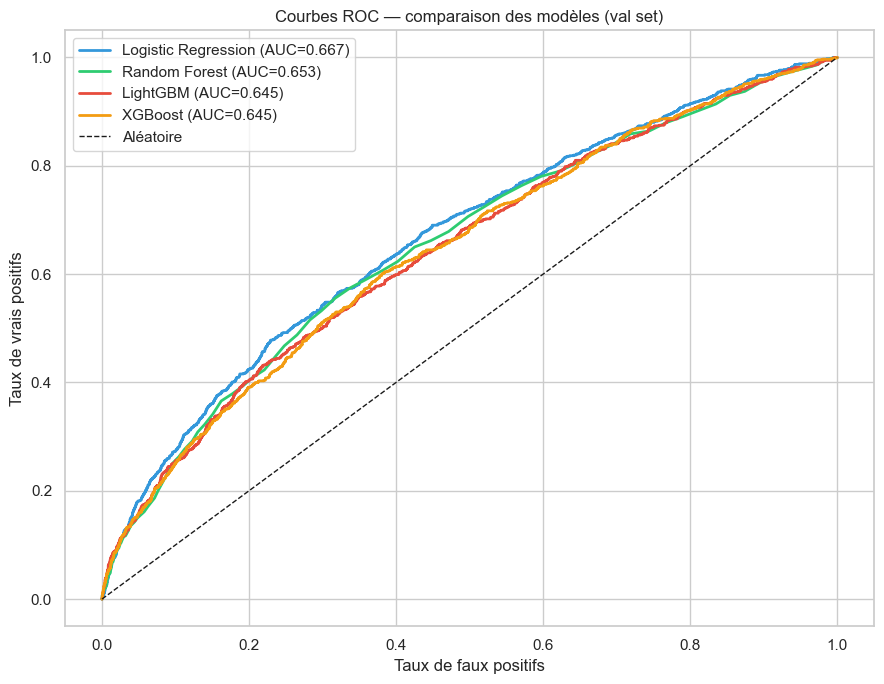

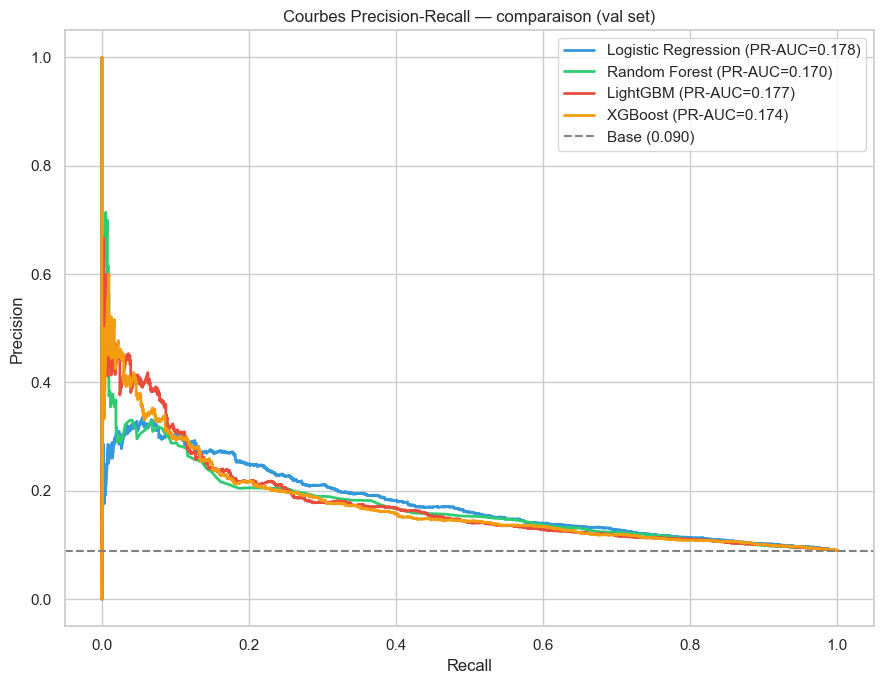

In [10]:
# =============================================================
# SECTION 9 — VISUALISATIONS COMPARATIVES
# =============================================================

couleurs = {"Logistic Regression": "#3498DB", "Random Forest": "#2ECC71",
            "LightGBM": "#E74C3C", "XGBoost": "#F39C12"}

# --- (a) Courbes ROC ---
plt.figure(figsize=(9, 7))
for nom, model in modeles_entraines.items():
    proba = model.predict_proba(X_val)[:, 1]
    fpr, tpr, _ = roc_curve(y_val, proba)
    auc = roc_auc_score(y_val, proba)
    plt.plot(fpr, tpr, color=couleurs[nom], lw=2, label=f"{nom} (AUC={auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", lw=1, label="Aléatoire")
plt.xlabel("Taux de faux positifs")
plt.ylabel("Taux de vrais positifs")
plt.title("Courbes ROC — comparaison des modèles (val set)")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES / "roc_curves_all_models.png", dpi=120)
plt.show()

# --- (b) Courbes Precision-Recall ---
plt.figure(figsize=(9, 7))
for nom, model in modeles_entraines.items():
    proba = model.predict_proba(X_val)[:, 1]
    prec, rec, _ = precision_recall_curve(y_val, proba)
    ap = average_precision_score(y_val, proba)
    plt.plot(rec, prec, color=couleurs[nom], lw=2, label=f"{nom} (PR-AUC={ap:.3f})")
plt.axhline(y_val.mean(), ls="--", color="gray", label=f"Base ({y_val.mean():.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Courbes Precision-Recall — comparaison (val set)")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES / "pr_curves_all_models.png", dpi=120)
plt.show()

### 📈 Lecture des courbes ROC et Precision-Recall

**Les courbes PR sont plus informatives que les ROC ici.** En contexte de fort
déséquilibre (~9% de positifs), la courbe ROC peut paraître flatteuse car elle
intègre les vrais négatifs (très nombreux et faciles). La courbe **Precision-Recall**
se concentre sur la classe minoritaire — celle qui nous intéresse — et reflète mieux
la difficulté réelle. La ligne de base (precision = taux de positifs ≈ 0.09) rappelle
le point de départ d'un classifieur aléatoire.

**Les 4 modèles sont proches sur les courbes.** Aucun ne domine nettement, ce qui
confirme que la limite vient des **données** (signal faible) plutôt que du choix du
modèle. Les modèles à base d'arbres (LightGBM, XGBoost) ont un léger avantage sur
la PR-AUC.

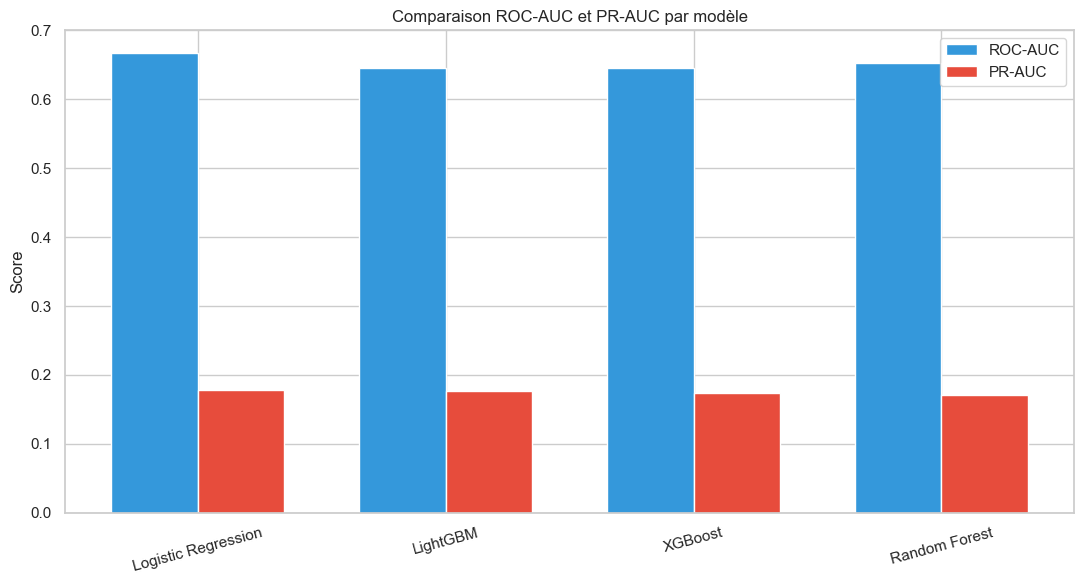

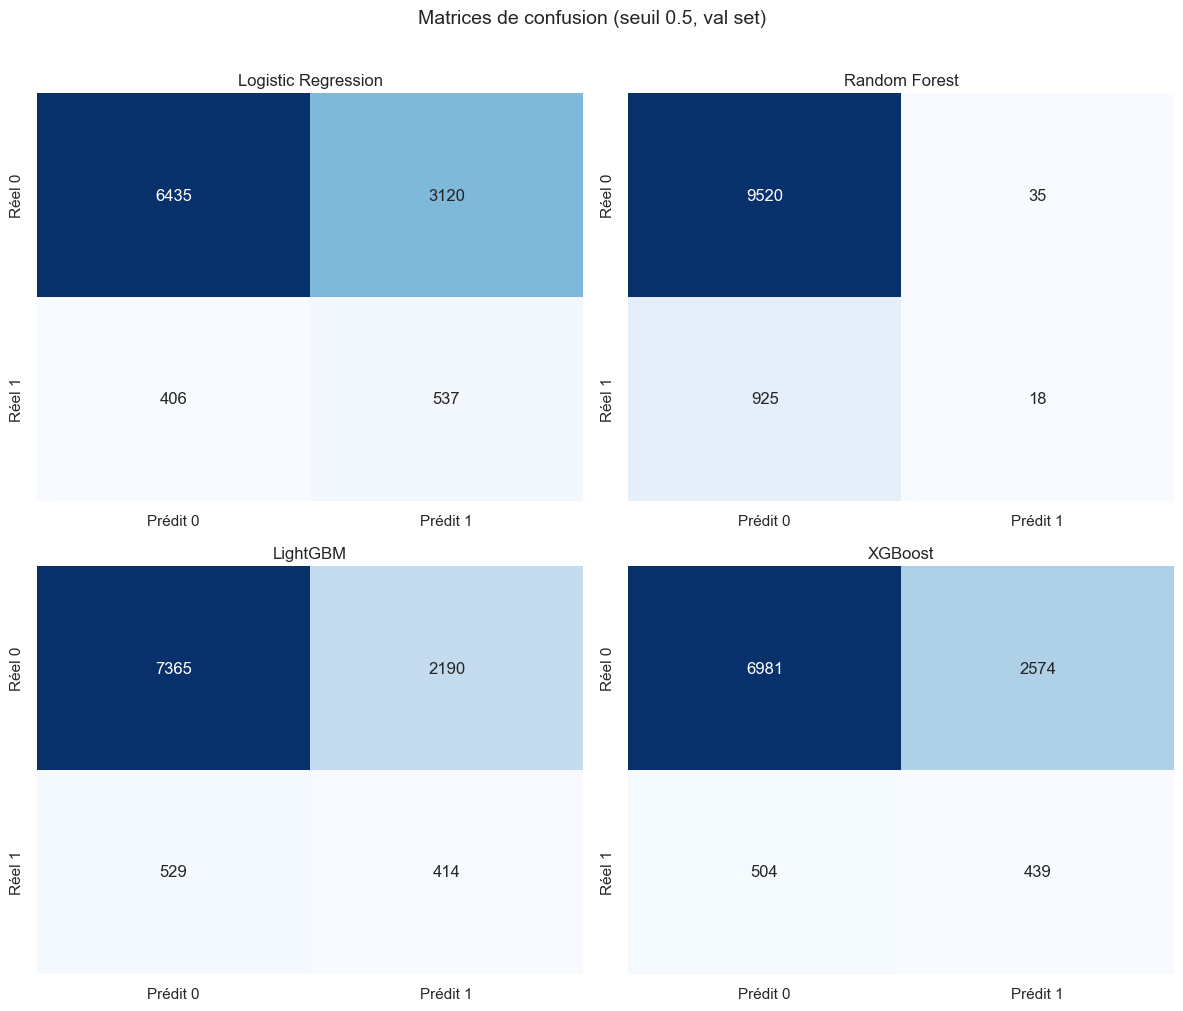

In [11]:
# =============================================================
# SECTION 9 (suite) — BAR CHART ET MATRICES DE CONFUSION
# =============================================================

# --- (c) Bar chart ROC-AUC vs PR-AUC ---
fig, ax = plt.subplots(figsize=(11, 6))
noms = df_results.index.tolist()
x = np.arange(len(noms))
largeur = 0.35
ax.bar(x - largeur/2, df_results["ROC-AUC"], largeur, label="ROC-AUC", color="#3498DB")
ax.bar(x + largeur/2, df_results["PR-AUC"],  largeur, label="PR-AUC",  color="#E74C3C")
ax.set_xticks(x)
ax.set_xticklabels(noms, rotation=15)
ax.set_ylabel("Score")
ax.set_title("Comparaison ROC-AUC et PR-AUC par modèle")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES / "metrics_comparison_barchart.png", dpi=120)
plt.show()

# --- (d) Matrices de confusion (seuil 0.5) ---
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, (nom, model) in zip(axes.ravel(), modeles_entraines.items()):
    y_pred = model.predict(X_val)
    cm = confusion_matrix(y_val, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax, cbar=False,
                xticklabels=["Prédit 0", "Prédit 1"],
                yticklabels=["Réel 0", "Réel 1"])
    ax.set_title(f"{nom}")
plt.suptitle("Matrices de confusion (seuil 0.5, val set)", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(FIGURES / "confusion_matrices.png", dpi=120)
plt.show()

### 🔍 Lecture des matrices de confusion (seuil 0.5)

Les matrices révèlent le compromis **recall / precision** de chaque modèle au seuil 0.5 :

- **Random Forest** : quasi aucune prédiction positive → faux négatifs massifs.
  Inutilisable tel quel pour la priorité médicale (détecter les patients à risque).
- **LightGBM / XGBoost** : détectent 44-47% des cas positifs, avec beaucoup de faux
  positifs (precision ~0.15). C'est le compromis attendu quand on privilégie le recall.
- **Logistic Regression** : recall le plus élevé (0.57) au seuil 0.5, mais precision
  parmi les plus basses.

**Priorité médicale = minimiser les faux négatifs** (un patient à risque non détecté
est plus grave qu'une fausse alerte). Aucun modèle n'atteint un recall satisfaisant
au seuil 0.5 : c'est pourquoi l'**optimisation du seuil** au NB06 sera déterminante
pour remonter le recall, quitte à sacrifier de la precision.

In [12]:
# =============================================================
# SECTION 10 — SÉLECTION DU MODÈLE CHAMPION
# =============================================================

# Hiérarchie de sélection justifiée par le contexte clinique :
#   1. PR-AUC : pouvoir discriminant (métrique prioritaire vu le déséquilibre)
#   2. Si les modèles sont PROCHES en PR-AUC (écart < 0.005), ils sont
#      considérés équivalents en discrimination → on départage sur la
#      CALIBRATION (Brier Score), cruciale pour un dashboard clinique où
#      les probabilités sont montrées au praticien.
#   3. Recall en dernier recours (priorité médicale).

SEUIL_EQUIVALENCE = 0.005  # en-deçà, les PR-AUC sont jugées équivalentes

# Meilleure PR-AUC
pr_auc_max = df_results["PR-AUC"].max()

# Modèles "en lice" : ceux dont la PR-AUC est à moins de 0.005 du meilleur
en_lice = df_results[df_results["PR-AUC"] >= pr_auc_max - SEUIL_EQUIVALENCE]

if len(en_lice) == 1:
    # Un seul modèle domine nettement sur la PR-AUC
    champion = en_lice.index[0]
    note = f"(PR-AUC nettement supérieure)"
else:
    # Plusieurs modèles équivalents en PR-AUC → départage sur la CALIBRATION
    # (Brier Score le plus bas = probabilités les plus fiables)
    champion = en_lice["Brier Score"].idxmin()
    note = (f"({len(en_lice)} modèles équivalents en PR-AUC "
            f"[écart < {SEUIL_EQUIVALENCE}] → départage sur la calibration/Brier)")

print("=" * 60)
print("MODÈLE CHAMPION")
print("=" * 60)
print(f"  🏆 {champion}")
print(f"  {note}")
print(f"\n  Modèles en lice (PR-AUC équivalente) :")
for m in en_lice.index:
    print(f"    {m:<22} PR-AUC={df_results.loc[m,'PR-AUC']:.4f} | "
          f"Brier={df_results.loc[m,'Brier Score']:.4f}")

print(f"\n  Champion retenu : {champion}")
print(f"    PR-AUC    : {df_results.loc[champion, 'PR-AUC']:.4f}")
print(f"    Brier     : {df_results.loc[champion, 'Brier Score']:.4f}  (calibration)")
print(f"    Recall    : {df_results.loc[champion, 'Recall']:.4f}")
print(f"    ROC-AUC   : {df_results.loc[champion, 'ROC-AUC']:.4f}")

# Sauvegarde du nom
with open(REPORTS / "best_model_name.txt", "w") as f:
    f.write(champion)
print(f"\n✓ Champion sauvegardé : reports/best_model_name.txt")
print("\n➡️  Prochaine étape : NB05 — Optimisation (Optuna) du champion")

MODÈLE CHAMPION
  🏆 LightGBM
  (3 modèles équivalents en PR-AUC [écart < 0.005] → départage sur la calibration/Brier)

  Modèles en lice (PR-AUC équivalente) :
    Logistic Regression    PR-AUC=0.1784 | Brier=0.2277
    LightGBM               PR-AUC=0.1766 | Brier=0.1825
    XGBoost                PR-AUC=0.1737 | Brier=0.1963

  Champion retenu : LightGBM
    PR-AUC    : 0.1766
    Brier     : 0.1825  (calibration)
    Recall    : 0.4390
    ROC-AUC   : 0.6449

✓ Champion sauvegardé : reports/best_model_name.txt

➡️  Prochaine étape : NB05 — Optimisation (Optuna) du champion


### 🏆 Sélection du champion : LightGBM

Les 3 meilleurs modèles sont **équivalents en PR-AUC** (écarts < 0,005), donc
équivalents en pouvoir discriminant. Le départage se fait alors sur un critère
décisif pour ce projet : la **calibration** (Brier Score), car le dashboard
Streamlit montre des probabilités au praticien — elles doivent être fiables.

| Modèle (en lice) | PR-AUC | Brier (calibration) |
|---|---|---|
| Logistic Regression | 0,1784 | 0,2277 |
| **LightGBM** | 0,1766 | **0,1825** ✓ |
| XGBoost | 0,1737 | 0,1963 |

**LightGBM est retenu** : à pouvoir discriminant équivalent, c'est le mieux calibré.
Il gère aussi les interactions non-linéaires et reste cohérent avec la suite du
pipeline (TreeSHAP, calibration). La Logistic Regression, marginalement en tête sur
la PR-AUC, aurait exigé plus de calibration.

## 🏁 Conclusion du NB05

### Modèle champion : LightGBM
Les 3 meilleurs modèles sont **équivalents en PR-AUC** (écarts < 0.005) :
- Logistic Regression (0.1784), LightGBM (0.1766), XGBoost (0.1737).
- À pouvoir discriminant équivalent, le départage se fait sur la **calibration**
  (Brier Score), cruciale car le dashboard Streamlit montre des probabilités au
  praticien. LightGBM est le mieux calibré (Brier 0.1825 vs 0.2277 pour la LR),
  d'où sa sélection.

### Ce que ces baselines nous apprennent
1. Le problème est **difficile** (signal faible) — scores modestes mais réalistes.
2. Le **seuil 0.5 est inadapté** au déséquilibre — à optimiser au NB06.
3. Les modèles sont **quasi équivalents** — LightGBM retenu pour sa calibration.
4. Aucun leakage détecté (scores cohérents avec la littérature).

### Limites assumées à ce stade
- Hyperparamètres par défaut (non optimisés) → NB05.
- Seuil de décision fixe à 0.5 → NB06.
- Comparaison sur un seul découpage val → CV au NB05.

### Prochaine étape
**NB06 — Optimisation** de LightGBM par Optuna (recherche bayésienne, CV 5-fold,
métrique PR-AUC), pour améliorer les performances au-delà des réglages par défaut.